# Anomaly Detection on mlg-ulb Credit Card Fraud Data

## 1. Problem Framing

Anomaly detection is the identification of data points that do not align with expected values. By detecting such inconsistencies in a data set, valuable insights can be drawn. In the context of this project, these anomalies can help identify fraudulent credit card transactions.

In unsupervised learning, patterns and structure are inferred directly from the data without the use of labeled outcomes. In contrast, supervised learning relies on predefined labels and aims to learn a mapping between input features and those labels.

Although the dataset we are using includes a `class` feature that indicates if the transaction is legitimate (0) or fraudulent (1), this project is framed as an unsupervised anomaly detection problem. The explored detection methods are designed to identify anomalies without relying on labelled data during training.


This approach better represents real-world fraud detection scenarios, where fraudulent activities are evolving and not fully labeled in advance. Thus, the `class` labels will be used in the evaluation, not the training of our unsupervised methods.

## 2. Detection Methods

### Preprocessing

⚠️ TODO ⚠️ should we drop time?

⚠️ TODO ⚠️ should we remove outliers?

The `Class` label was removed from training to maintain an unsupervised learning framework, but retained for evaluation. The `Time` feature was removed as it represents a relative timestamp with limited standalone predictive value. Features were standardized using z-score normalization to ensure consistent scaling across dimensions.

In [9]:
import pandas as pd 
from sklearn.preprocessing import StandardScaler 

def get_dataset(filename="archive/creditcard.csv"): 
    df = pd.read_csv(filename) 
    
    # Identify any missing values: 
    values = df.isnull().sum() 
    print(values[values > 0]) 
    
    # Unsupervised, so drop Class in X 
    df_dropped = df.drop(columns=['Class', 'Time']) 
    y = df['Class'] 
    
    # These samples are already time-ordered, so we simply split them such that 
    # train = transactions in the past, test = transactions in the future 
    split_idx = int(len(df) * 0.8) 
    X_train = df_dropped.iloc[:split_idx] 
    X_test = df_dropped.iloc[split_idx:] 
    y_train = y.iloc[:split_idx] 
    y_test = y.iloc[split_idx:] 
    
    # Normalize the features 
    scaler = StandardScaler() 
    X_train = scaler.fit_transform(X_train) 
    X_test = scaler.transform(X_test) 
    
    return X_train, X_test, y_train, y_test

### Statistical Method: Moving Average

In [14]:
import numpy as np
import pandas as pd

def moving_average_detector(
    X_train,
    X_test,
    y_test,
    window_size=50,
    quantile=0.99
):
    # Create DataFrames
    X_train_df = pd.DataFrame(X_train)
    X_test_df = pd.DataFrame(X_test)

    #########
    # TRAIN #
    #########

    train_mean = X_train_df.rolling(
        window=window_size,
        min_periods=window_size
    ).mean()

    train_std = X_train_df.rolling(
        window=window_size,
        min_periods=window_size
    ).std().replace(0, np.nan)

    train_z = (X_train_df - train_mean) / train_std
    train_scores = np.sqrt((train_z ** 2).sum(axis=1))

    # Threshold from train only
    threshold = train_scores.quantile(quantile)

    ########
    # TEST #
    ########

    # Give the test set the recent past from training
    X_combined = pd.concat(
        [X_train_df.iloc[-(window_size - 1):], X_test_df],
        ignore_index=True
    )

    test_mean = X_combined.rolling(
        window=window_size,
        min_periods=window_size
    ).mean()

    test_std = X_combined.rolling(
        window=window_size,
        min_periods=window_size
    ).std().replace(0, np.nan)

    test_z = (X_combined - test_mean) / test_std
    test_scores_all = np.sqrt((test_z ** 2).sum(axis=1))

    # Drop the train scores, keep test scores. The higher the score, the more
    # likely the sample is an anomaly.
    test_scores = test_scores_all.iloc[window_size - 1:].reset_index(drop=True)

    # Binary predictions
    y_pred = (test_scores > threshold).astype(int)

    # Replace the current index with 0, 1, 2, etc
    y_test_reset = y_test.reset_index(drop=True)

    return {
        "y_true": y_test_reset,
        "y_pred": y_pred,
        "scores": test_scores,
        "threshold": threshold
    }

X_train, X_test, y_train, y_test = get_dataset()

ma_output = moving_average_detector(
    X_train=X_train,
    X_test=X_test,
    y_test=y_test,
    window_size=50,
    quantile=0.99
)

Series([], dtype: int64)


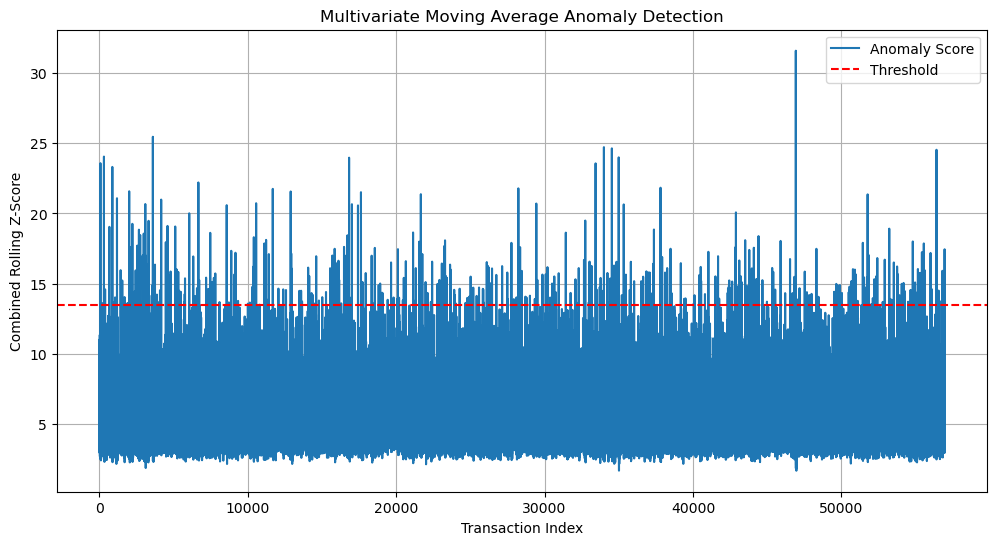

In [16]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
plt.plot(ma_output['scores'], label='Anomaly Score')
plt.axhline(y=ma_output['threshold'], color='r', linestyle='--', label='Threshold')
plt.xlabel('Transaction Index')
plt.ylabel('Combined Rolling Z-Score')
plt.title('Multivariate Moving Average Anomaly Detection')
plt.legend()
plt.grid(True)
plt.show()

In [5]:
from sklearn.metrics import precision_score, recall_score, f1_score

# Make a list of indexes that only point to non-nane (0 or 1) values
valid_idx = results['anomaly_score'].notna()

y_true = y[valid_idx]
y_pred = pred[valid_idx]

precision = precision_score(y_true, y_pred)
recall = recall_score(y_true, y_pred)
f1 = f1_score(y_true, y_pred)

print(f"Precision: {precision*100:.2f}%")
print(f"Recall:    {recall*100:.2f}%")
print(f"F1 Score:  {f1*100:.2f}%")

Precision: 8.49%
Recall:    49.19%
F1 Score:  14.49%


### Distance-based Method: kNN

### ML Method: Isolation Forest

### Bonus: Deep Learning-based method

## 3. Threshold Optimization

## 4. Evaluation

## 5. Interpretability

## 6. Experiment Tracking